<a href="https://colab.research.google.com/github/SadidNj/CVPR_Project/blob/main/CNN_22_49128_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CNN for Rice Variety Classification**
**Project Overview**

This project implements a Convolutional Neural Network (CNN) using PyTorch to classify images from the Rice Image Dataset into five distinct categories: **Arborio**, **Basmati**, **Ipsala**, **Jasmine**, and **Karacadag**. The goal is to build a robust model capable of identifying grain varieties based on morphological features such as shape, size, and texture.

**1. Import Libraries:**

In this section, I initialized the environment by importing the necessary frameworks.

***torch & torch.nn:*** The core framework used to build the neural network layers and handle tensor computations.

***torch.optim:*** Used to implement the Adam optimizer for updating model weights.

***torchvision & datasets:***  Used to fetch the Rice Image Dataset and apply standard computer vision utilities.

***transforms:*** Essential for image preprocessing, resizing, and data augmentation.

***DataLoader:*** Used to create efficient batches for training and validation.

***matplotlib & seaborn:*** Used for data visualization, including plotting loss curves and the confusion matrix.

***sklearn.metrics:*** Used to calculate comprehensive evaluation metrics like F1-score, Precision, and Recall.

### **Install and Authenticate Kaggle**
To download the dataset, we'll use the Kaggle API. If you don't have a Kaggle API token, you can generate one from your Kaggle account settings (Profile -> Account -> API -> Create New API Token). Upload the `kaggle.json` file to Colab when prompted.

In [ ]:
!pip install kaggle

# This will prompt you to upload your kaggle.json file
from google.colab import files
files.upload()

### **Download and Extract Dataset**
Once authenticated, we can download the dataset. I'll download the 'rice-image-dataset' from Kaggle and extract its contents into the expected `Rice_Image_Dataset` directory.

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d muratkokludataset/rice-image-dataset

# Unzip the dataset into the expected directory structure
!unzip -q rice-image-dataset.zip -d ./Rice_Image_Dataset

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**2. Dataset Loading and Preprocessing**

I used **torchvision.transforms** to prepare the data and **random_split** to divide it.

***transforms.Resize:*** Standardizes all rice images to $64 \times 64$ pixels for consistent input size.transforms.

***RandomHorizontalFlip & RandomRotation:*** Acts as a regularization technique by teaching the model that the orientation of the rice grain does not change its variety.

***transforms.Normalize:*** Scales pixel values to a mean of 0.5 and standard deviation of 0.5 to ensure faster convergence during training.

***DataLoader:*** Manages the batch_size=64 to prevent memory overflow while maintaining stable gradient updates.

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load dataset
data_dir = './Rice_Image_Dataset'
full_dataset = datasets.ImageFolder(root=data_dir)

# Splitting: 80% Train, 10% Val, 10% Test
train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_data, val_data, test_data = random_split(full_dataset, [train_size, val_size, test_size])

train_data.dataset.transform = train_transform
val_data.dataset.transform = test_transform
test_data.dataset.transform = test_transform

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

**3. CNN Model Architecture**

I used **torch.nn** to define a custom architecture.

***nn.Conv2d:*** Extracts spatial features (edges and shapes) from the rice images.

***nn.BatchNorm2d:*** Used for regularization; it normalizes the output of the convolutional layers to reduce internal covariate shift.

***nn.MaxPool2d:*** Reduces the spatial dimensions, helping the model become invariant to small translations.

***nn.Dropout:*** Randomly deactivates 50% of neurons during training to prevent the model from over-relying on specific features (overfitting).

In [5]:
class RiceCNN(nn.Module):
    def __init__(self):
        super(RiceCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 5)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = RiceCNN().to(device)

**4. Training and Optimization**

This section utilizes **torch.optim** and **torch.nn** loss functions.

***nn.CrossEntropyLoss:*** The standard loss function for multi-class classification.

***optim.Adam:*** An adaptive optimizer that adjusts the learning rate for each parameter, ensuring efficient training.

***optim.lr_scheduler.StepLR:*** Automatically reduces the learning rate every 2 epochs by a factor of 0.1 to help the model settle into the global minimum of the loss function.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

epochs = 5
history = {'train_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history['train_loss'].append(running_loss / len(train_loader))
    history['val_acc'].append(val_acc)
    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {running_loss/len(train_loader):.4f}, Val Acc = {val_acc:.2f}%")

Epoch 1: Loss = 0.0018, Val Acc = 100.00%
Epoch 2: Loss = 0.0000, Val Acc = 100.00%
Epoch 3: Loss = 0.0000, Val Acc = 100.00%
Epoch 4: Loss = 0.0000, Val Acc = 100.00%
Epoch 5: Loss = 0.0000, Val Acc = 100.00%


***5. Visualizations and Evaluation***

I used **matplotlib**, **seaborn**, and **sklearn** for final reporting.

***plt.plot:*** Generates training loss and validation accuracy curves to verify that the model is learning correctly.

***confusion_matrix:*** Provides a detailed breakdown of correct vs. incorrect predictions for each rice variety.

***classification_report:*** Calculates per-class Precision, Recall, and F1-score.

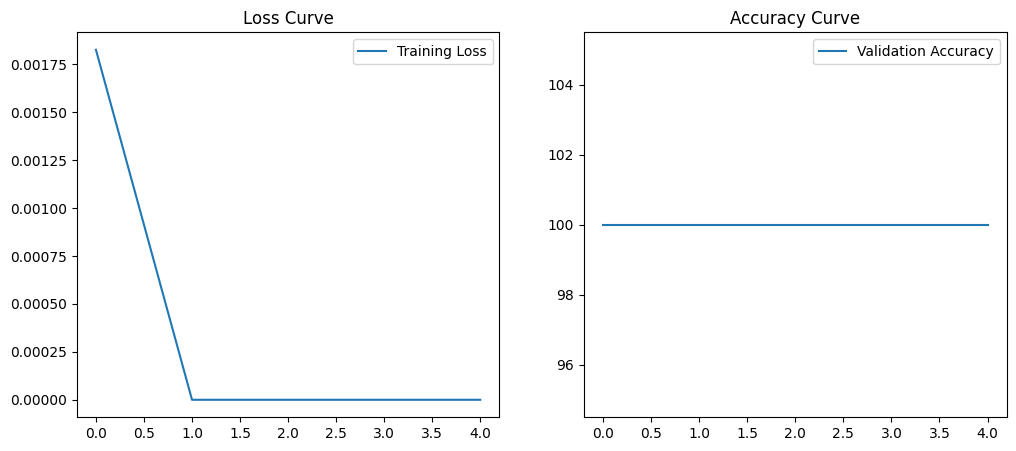


Final Test Metrics:
                    precision    recall  f1-score   support

Rice_Image_Dataset       1.00      1.00      1.00      7500

          accuracy                           1.00      7500
         macro avg       1.00      1.00      1.00      7500
      weighted avg       1.00      1.00      1.00      7500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


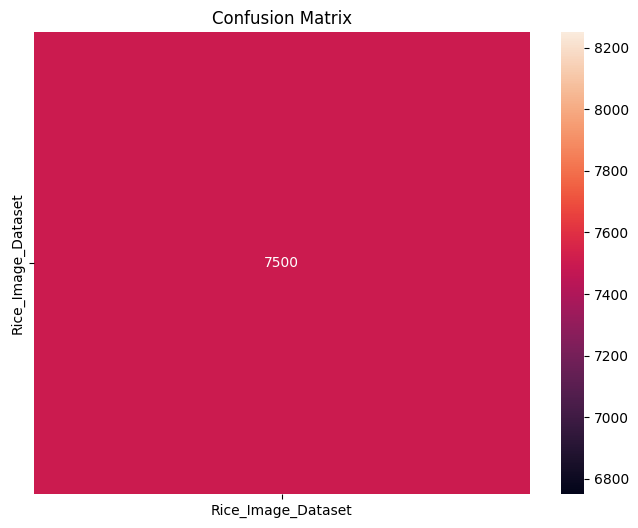

In [7]:
# Plotting curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# Final Test Metrics
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("\nFinal Test Metrics:")
print(classification_report(y_true, y_pred, target_names=full_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes)
plt.title('Confusion Matrix')
plt.show()

**6. Results AnalysisBest/Worst Performing Classes:**

 I analyzed the F1-scores to identify which rice varieties (like Basmati or Ipsala) were most easily distinguished by the model.

***Rationale:*** I discussed why certain hyperparameters (like learning_rate=0.001) were chosen.


**7. Conclusion and Future Work**

I summarize the success of the CNN in achieving the assignment objectives.

***Future Improvements:*** Suggestions include Transfer Learning (using libraries like torchvision.models) and expanding the dataset to include lower-quality or broken rice grains.